# Notebook 02: EDA and Modelling

**Bank Customer Churn Analysis — Analytics in Practise**

This notebook covers:
1. Exploratory Data Analysis (EDA) — confirming all key findings
2. Modelling — Logistic Regression, Random Forest, XGBoost
3. Model comparison and feature importance

Data source: pre-processed outputs from `01_data_cleaning_preprocessing.ipynb`

---
## 0. Setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Colour palette (brand-consistent with guide)
BRAND_NAVY   = '#1E2761'
BRAND_GOLD   = '#F4C430'
BRAND_RED    = '#D94F3D'
BRAND_GREEN  = '#3D9970'
BRAND_GREY   = '#AAAAAA'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Data' / 'Features').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root containing Data/Features')

PROJECT_ROOT  = find_project_root(Path.cwd())
FEATURES_DIR  = PROJECT_ROOT / 'Data' / 'Features'
IMAGES_DIR    = PROJECT_ROOT / 'Images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ──────────────────────────────────────────────────────────────
df_raw  = pd.read_csv(FEATURES_DIR / 'bank_customer_churn_features.csv')
train   = pd.read_csv(FEATURES_DIR / 'bank_customer_churn_train_features.csv')
test    = pd.read_csv(FEATURES_DIR / 'bank_customer_churn_test_features.csv')

# Re-derive readable country/gender labels for EDA
df = df_raw.copy()
df['country'] = np.where(df['country_Germany'], 'Germany',
                np.where(df['country_Spain'],   'Spain', 'France'))
df['gender']  = np.where(df['gender_Male'], 'Male', 'Female')

print('Full dataset shape :', df.shape)
print('Train shape        :', train.shape)
print('Test shape         :', test.shape)
print('Churn rate (full)  :', df['churn'].mean().round(4))

Full dataset shape : (10000, 15)
Train shape        : (8000, 12)
Test shape         : (2000, 12)
Churn rate (full)  : 0.2037


---
## 1. Exploratory Data Analysis

### 1.1 Dataset Overview

In [3]:
print('=== Shape & Types ===')
print(f'Rows: {len(df):,}   |   Columns: {df.shape[1]}')
display(df.dtypes.rename('dtype').to_frame())

print('\n=== Missing Values ===')
missing = df.isna().sum()
print('No missing values.' if missing.sum() == 0 else missing[missing > 0])

print('\n=== Descriptive Statistics (numeric) ===')
display(df[['credit_score','age','tenure','balance','products_number',
            'credit_card','active_member','estimated_salary']].describe().T)

=== Shape & Types ===
Rows: 10,000   |   Columns: 15


,dtype
customer_id,int64
credit_score,int64
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64
estimated_salary,float64
country_Germany,bool



=== Missing Values ===
No missing values.

=== Descriptive Statistics (numeric) ===


,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0000,650.5613,96.5587,383.0000,584.0000,652.0000,718.0000,850.0000
age,10000.0000,38.6608,9.7467,18.0000,32.0000,37.0000,44.0000,62.0000
tenure,10000.0000,5.0128,2.8922,0.0000,3.0000,5.0000,7.0000,10.0000
balance,10000.0000,76485.8893,62397.4052,0.0000,0.0000,97198.5400,127644.2400,250898.0900
products_number,10000.0000,1.5302,0.5817,1.0000,1.0000,1.0000,2.0000,4.0000
credit_card,10000.0000,0.7055,0.4558,0.0000,0.0000,1.0000,1.0000,1.0000
active_member,10000.0000,0.5151,0.4998,0.0000,0.0000,1.0000,1.0000,1.0000
estimated_salary,10000.0000,100090.2399,57510.4928,11.5800,51002.1100,100193.9150,149388.2475,199992.4800


### 1.2 Class Distribution (Churn vs Retained)

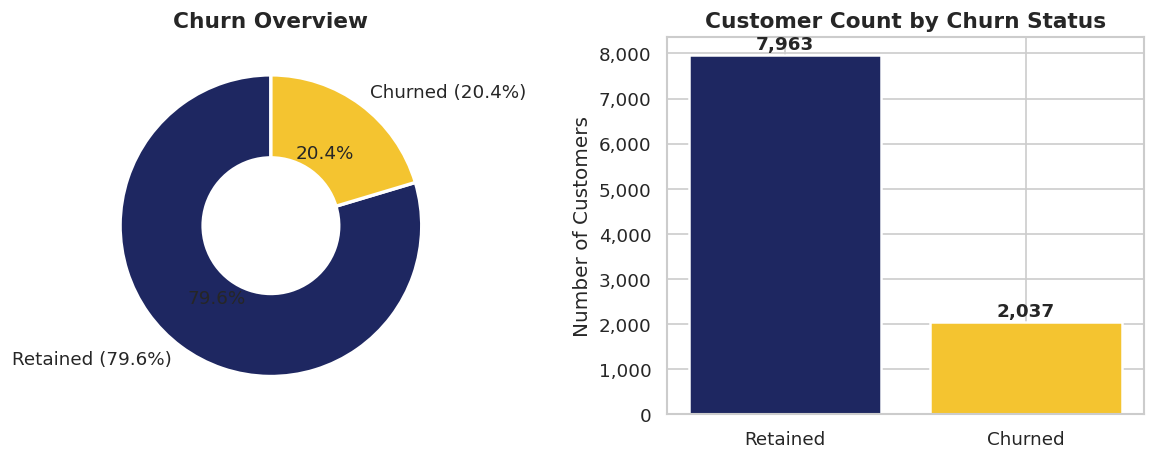


Churn rate: 20.4%  |  Churned: 2,037  |  Retained: 7,963


In [4]:
churn_counts = df['churn'].value_counts()
labels       = ['Retained (79.6%)', 'Churned (20.4%)']
colors       = [BRAND_NAVY, BRAND_GOLD]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Donut chart
axes[0].pie(
    churn_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
axes[0].set_title('Churn Overview', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['Retained', 'Churned'],
    churn_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart1_churn_overview.png', bbox_inches='tight')
plt.show()
print(f"\nChurn rate: {df['churn'].mean()*100:.1f}%  |  Churned: {churn_counts[1]:,}  |  Retained: {churn_counts[0]:,}")

### 1.3 Churn by Country — The Germany Anomaly

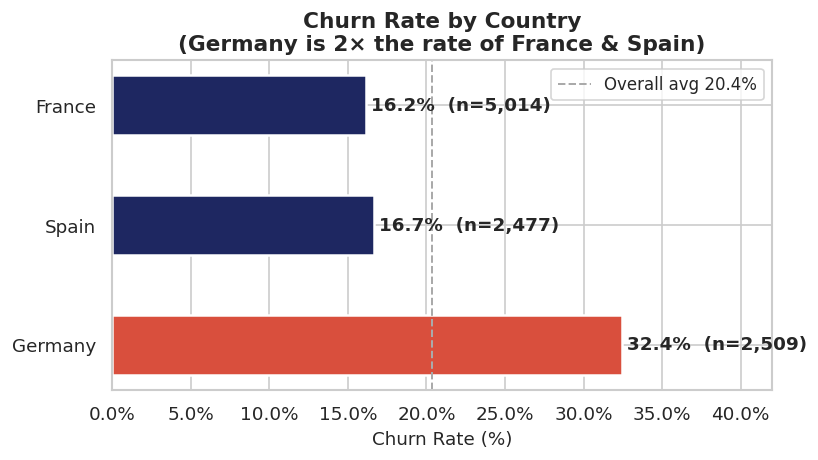

,Country,Churn Rate,Customers
1,Germany,32.4%,"2,509"
2,Spain,16.7%,"2,477"
0,France,16.2%,"5,014"


In [5]:
country_churn = df.groupby('country')['churn'].agg(['mean', 'count']).reset_index()
country_churn.columns = ['Country', 'Churn Rate', 'Customers']
country_churn = country_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [BRAND_RED if c == 'Germany' else BRAND_NAVY for c in country_churn['Country']]
bars = ax.barh(country_churn['Country'], country_churn['Churn Rate'] * 100,
               color=bar_colors, edgecolor='white', linewidth=1.5, height=0.5)

for bar, (_, row) in zip(bars, country_churn.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['Churn Rate']*100:.1f}%  (n={row['Customers']:,})",
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Rate by Country\n(Germany is 2× the rate of France & Spain)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 42)
ax.axvline(x=df['churn'].mean()*100, color=BRAND_GREY, linestyle='--', linewidth=1.2, label=f'Overall avg {df["churn"].mean()*100:.1f}%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart2_churn_by_country.png', bbox_inches='tight')
plt.show()

display(country_churn.style.format({'Churn Rate': '{:.1%}', 'Customers': '{:,}'}))

### 1.4 The Product Paradox — KEY FINDING

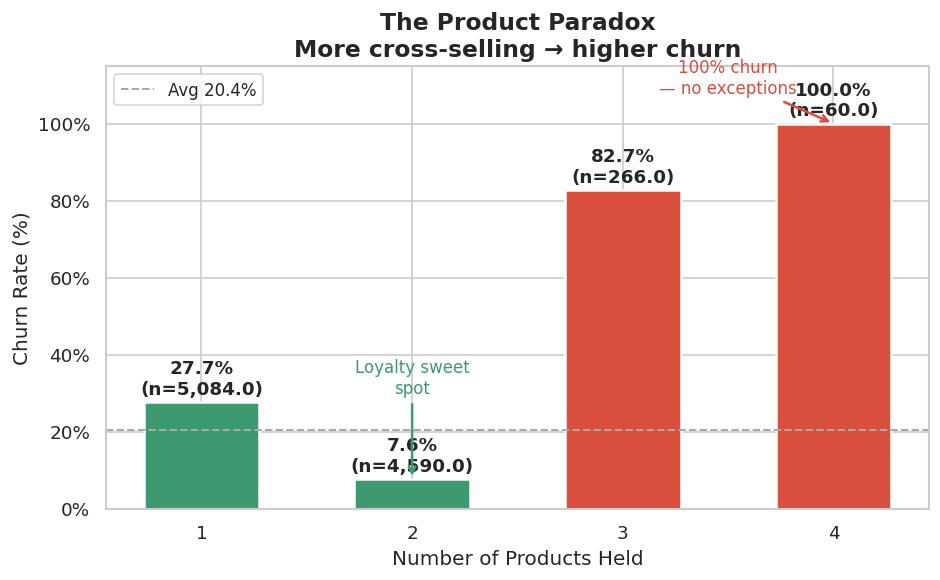

,Products,Churn Rate,Customers
0,1,27.7%,"5,084"
1,2,7.6%,"4,590"
2,3,82.7%,266
3,4,100.0%,60


In [6]:
prod_churn = df.groupby('products_number')['churn'].agg(['mean', 'count']).reset_index()
prod_churn.columns = ['Products', 'Churn Rate', 'Customers']

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [BRAND_GREEN, BRAND_GREEN, BRAND_RED, BRAND_RED]
bars = ax.bar(prod_churn['Products'].astype(str), prod_churn['Churn Rate'] * 100,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, (_, row) in zip(bars, prod_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['Churn Rate']*100:.1f}%\n(n={row['Customers']:,})",
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Products Held', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('The Product Paradox\nMore cross-selling → higher churn', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(y=df['churn'].mean()*100, color=BRAND_GREY, linestyle='--', linewidth=1.2, label=f'Avg {df["churn"].mean()*100:.1f}%')
ax.set_ylim(0, 115)
ax.legend(fontsize=10)

# Annotations
ax.annotate('Loyalty sweet\nspot', xy=(1, 7.6), xytext=(1, 30),
            arrowprops=dict(arrowstyle='->', color=BRAND_GREEN, lw=1.5),
            color=BRAND_GREEN, fontsize=10, ha='center')
ax.annotate('100% churn\n— no exceptions', xy=(3, 100), xytext=(2.5, 108),
            arrowprops=dict(arrowstyle='->', color=BRAND_RED, lw=1.5),
            color=BRAND_RED, fontsize=10, ha='center')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart3_product_paradox.png', bbox_inches='tight')
plt.show()

display(prod_churn.style.format({'Churn Rate': '{:.1%}', 'Customers': '{:,}'}))

### 1.5 Age Distribution by Churn — The 40+ Effect

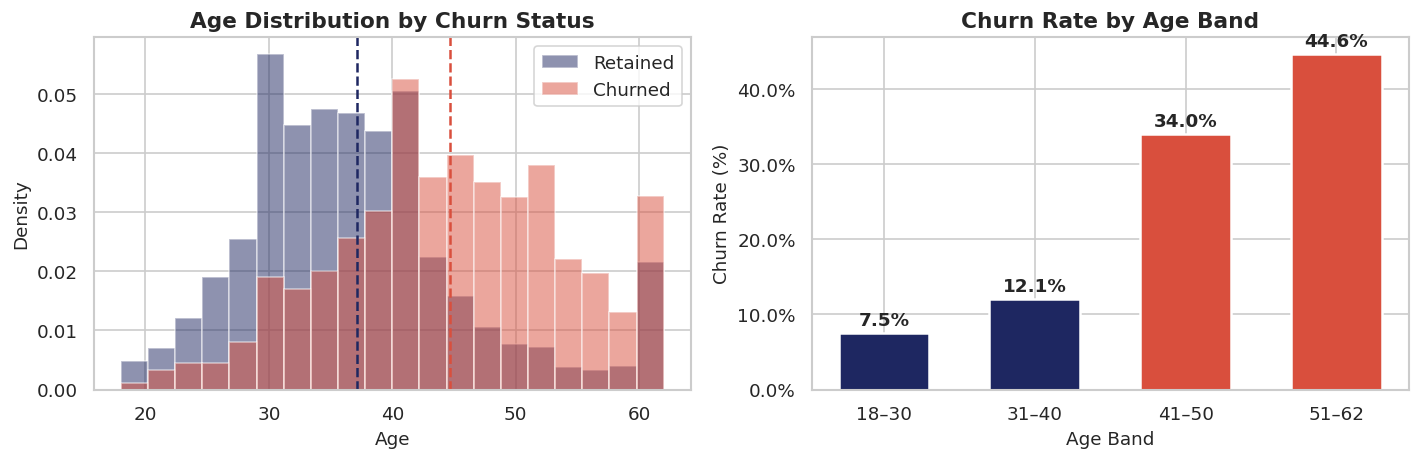

Mean age — Retained: 37.1
Mean age — Churned:  44.7


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE plot
for label, grp in df.groupby('churn'):
    name  = 'Churned' if label == 1 else 'Retained'
    color = BRAND_RED if label == 1 else BRAND_NAVY
    axes[0].hist(grp['age'], bins=20, alpha=0.5, color=color, label=name, density=True)
    axes[0].axvline(grp['age'].mean(), color=color, linestyle='--', linewidth=1.5)

axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Age Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0].legend()

# Churn rate by age band
df['age_band'] = pd.cut(df['age'], bins=[17,30,40,50,62],
                        labels=['18–30','31–40','41–50','51–62'])
age_churn = df.groupby('age_band', observed=True)['churn'].mean() * 100
bars = axes[1].bar(age_churn.index.astype(str), age_churn.values,
                   color=[BRAND_NAVY, BRAND_NAVY, BRAND_RED, BRAND_RED],
                   edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, age_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Age Band', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate by Age Band', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart4_age_distribution.png', bbox_inches='tight')
plt.show()

print('Mean age — Retained:', df[df['churn']==0]['age'].mean().round(1))
print('Mean age — Churned: ', df[df['churn']==1]['age'].mean().round(1))

### 1.6 High-Value Segment at Risk (Age 40–60, Balance > €100k)

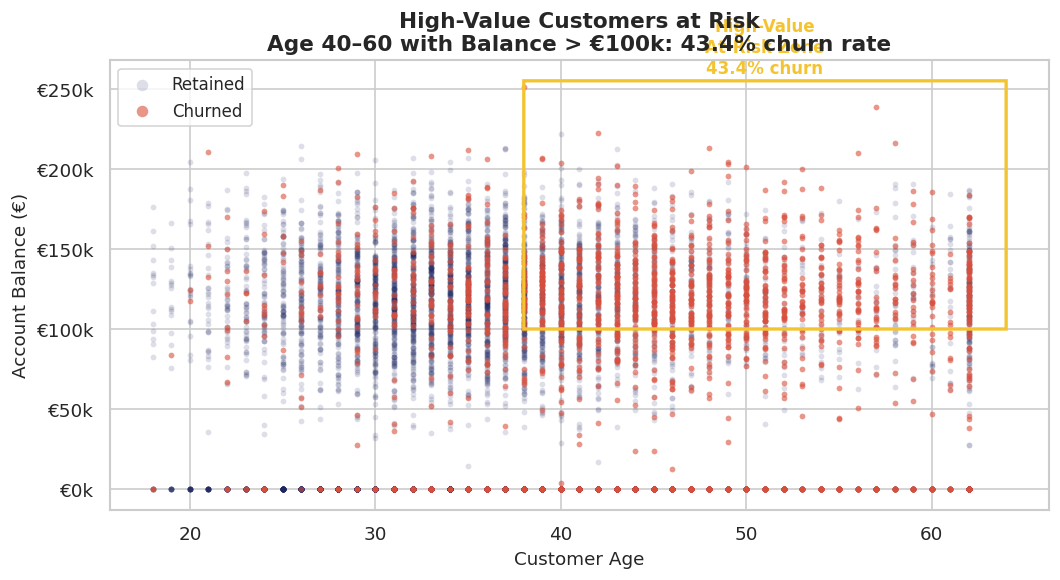

High-value segment: 1,767 customers | Churn rate: 43.4%


In [8]:
# Scatter: age vs balance, coloured by churn
fig, ax = plt.subplots(figsize=(9, 5))

for label, grp in df.groupby('churn'):
    name  = 'Churned' if label == 1 else 'Retained'
    color = BRAND_RED if label == 1 else BRAND_NAVY
    alpha = 0.6 if label == 1 else 0.15
    ax.scatter(grp['age'], grp['balance'], c=color, label=name,
               alpha=alpha, s=12, linewidths=0)

# Highlight high-value box
from matplotlib.patches import FancyBboxPatch
box = FancyBboxPatch((40, 100000), 22, 155000,
                     boxstyle='round,pad=2',
                     linewidth=2, edgecolor=BRAND_GOLD, facecolor='none')
ax.add_patch(box)
ax.text(51, 260000, 'High-Value\nAt-Risk Zone\n43.4% churn',
        ha='center', fontsize=10, color=BRAND_GOLD, fontweight='bold')

ax.set_xlabel('Customer Age', fontsize=11)
ax.set_ylabel('Account Balance (€)', fontsize=11)
ax.set_title('High-Value Customers at Risk\nAge 40–60 with Balance > €100k: 43.4% churn rate',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
ax.legend(markerscale=2, fontsize=10)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart5_high_value_scatter.png', bbox_inches='tight')
plt.show()

hv = df[(df['age'] >= 40) & (df['age'] <= 60) & (df['balance'] > 100_000)]
print(f'High-value segment: {len(hv):,} customers | Churn rate: {hv["churn"].mean()*100:.1f}%')

### 1.7 Gender Analysis Across Countries

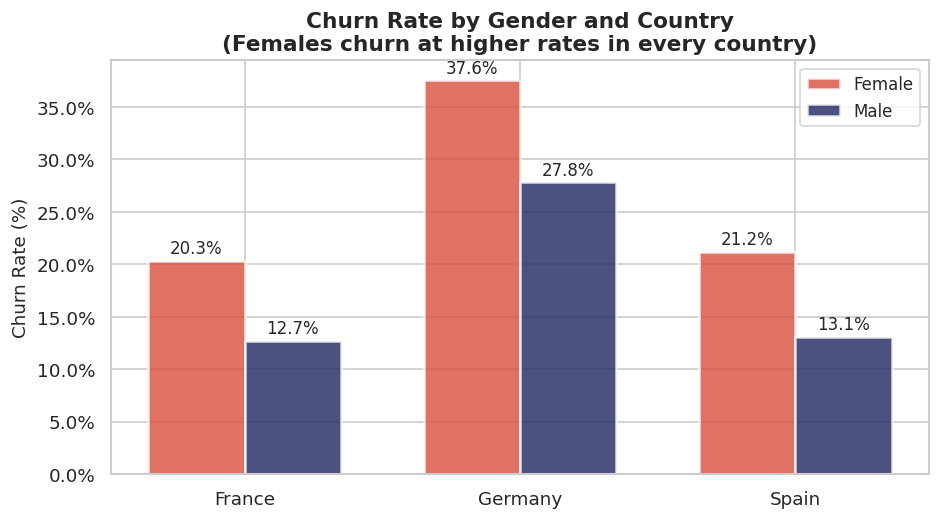

gender,Female,Male
country,,
France,20.3%,12.7%
Germany,37.6%,27.8%
Spain,21.2%,13.1%


In [9]:
gender_country = df.groupby(['country', 'gender'])['churn'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(gender_country.index))
width = 0.35

bars_f = ax.bar(x - width/2, gender_country['Female'], width, label='Female',
                color=BRAND_RED, alpha=0.8, edgecolor='white', linewidth=1.5)
bars_m = ax.bar(x + width/2, gender_country['Male'],   width, label='Male',
                color=BRAND_NAVY, alpha=0.8, edgecolor='white', linewidth=1.5)

for bars in [bars_f, bars_m]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(gender_country.index, fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Rate by Gender and Country\n(Females churn at higher rates in every country)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart6_gender_country.png', bbox_inches='tight')
plt.show()

display(gender_country.style.format('{:.1f}%'))

### 1.8 Activity & Key Segment Analysis

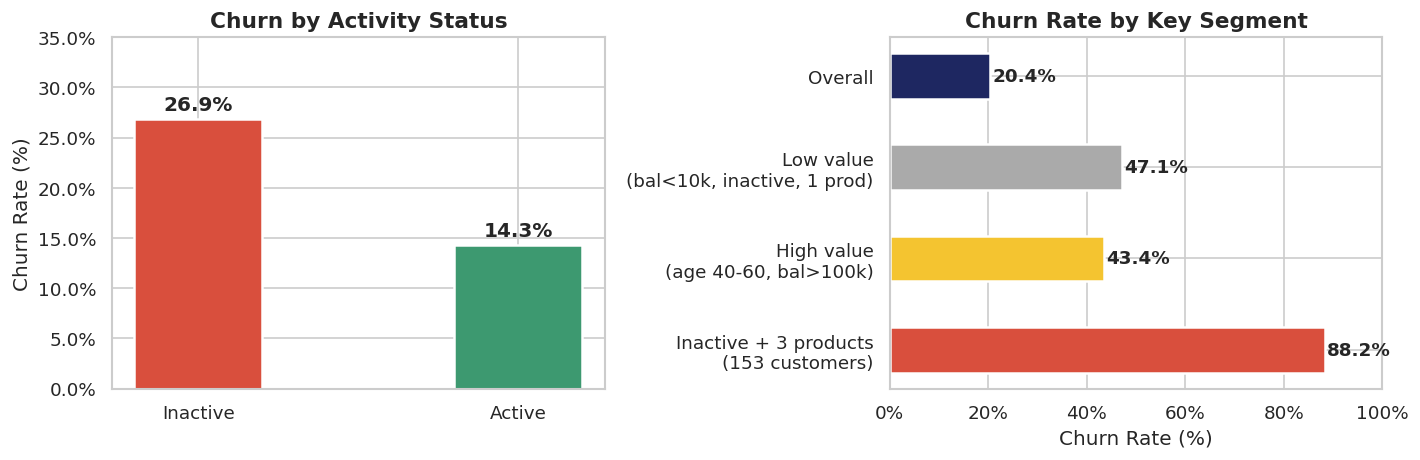

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Active vs Inactive
act_churn = df.groupby('active_member')['churn'].mean() * 100
bars = axes[0].bar(['Inactive', 'Active'], act_churn.values,
                   color=[BRAND_RED, BRAND_GREEN], edgecolor='white', linewidth=1.5, width=0.4)
for bar, val in zip(bars, act_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn by Activity Status', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, 35)

# Inactive + 3 products
segments = {
    'Inactive + 3 products\n(153 customers)': df[(df['active_member']==0) & (df['products_number']==3)]['churn'].mean() * 100,
    'High value\n(age 40-60, bal>100k)': df[(df['age']>=40) & (df['age']<=60) & (df['balance']>100000)]['churn'].mean() * 100,
    'Low value\n(bal<10k, inactive, 1 prod)': df[(df['balance']<10000) & (df['active_member']==0) & (df['products_number']==1)]['churn'].mean() * 100,
    'Overall': df['churn'].mean() * 100,
}
seg_colors = [BRAND_RED, BRAND_GOLD, BRAND_GREY, BRAND_NAVY]
bars2 = axes[1].barh(list(segments.keys()), list(segments.values()),
                     color=seg_colors, edgecolor='white', linewidth=1.5, height=0.5)
for bar, val in zip(bars2, segments.values()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Key Segment', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart7_segment_analysis.png', bbox_inches='tight')
plt.show()

### 1.9 Correlation Heatmap

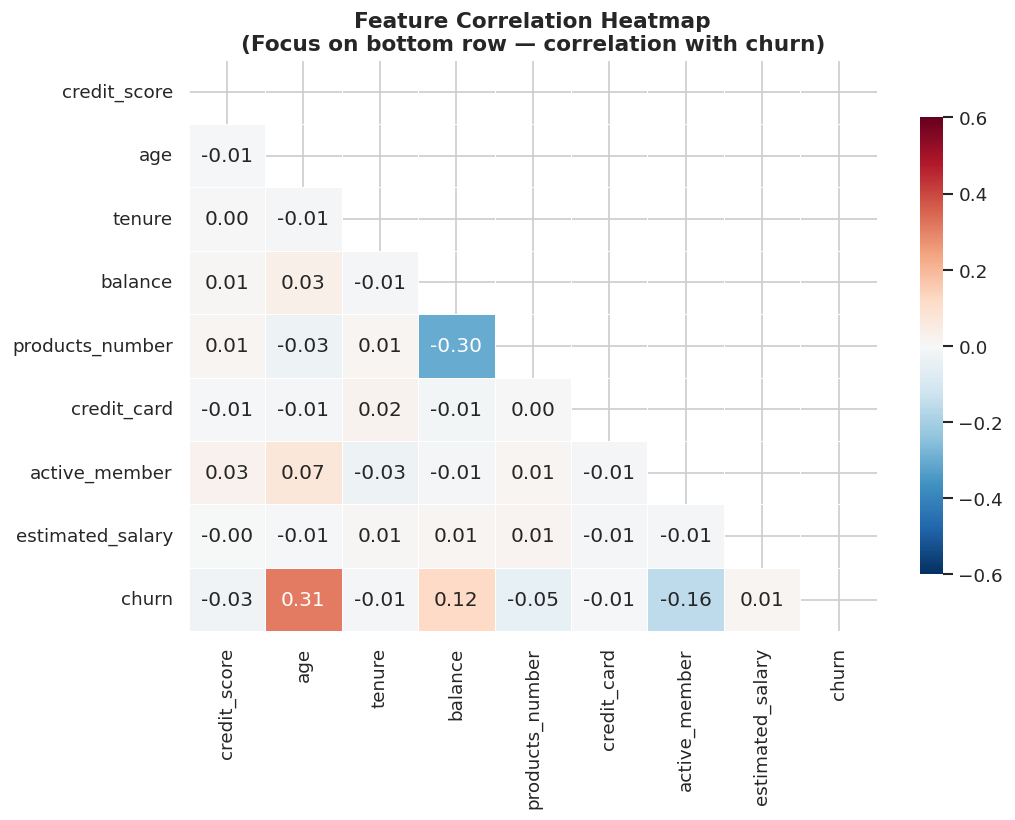


Correlation with churn (sorted):
age                 0.3120
active_member      -0.1560
balance             0.1190
products_number    -0.0480
credit_score       -0.0260
tenure             -0.0140
estimated_salary    0.0120
credit_card        -0.0070


In [11]:
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number',
                'credit_card', 'active_member', 'estimated_salary', 'churn']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap\n(Focus on bottom row — correlation with churn)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nCorrelation with churn (sorted):')
print(corr['churn'].drop('churn').sort_values(key=abs, ascending=False).round(3).to_string())

### 1.10 EDA Summary

| Finding | Value | Implication |
|---------|-------|-------------|
| Overall churn rate | 20.4% | ~2,037 customers lost |
| Germany churn rate | **32.4%** | 2× France & Spain — structural issue |
| 3-product churn | **82.7%** | Cross-selling strategy is backfiring |
| 4-product churn | **100%** | Every single one left |
| 2-product churn | **7.6%** | The loyalty sweet spot |
| Inactive + 3 products | **88.2%** | 153 highest-risk customers |
| High-value at-risk (age 40–60, bal>100k) | **43.4%** | Most financially damaging segment |
| Mean age churned vs retained | **44.7 vs 37.1** | Older customers leave more |
| Female churn (Germany) | **37.6%** | Highest gender-country combination |

---
## 2. Modelling

### 2.1 Prepare Train / Test Sets

In [12]:
X_train = train.drop('churn', axis=1)
y_train = train['churn']
X_test  = test.drop('churn', axis=1)
y_test  = test['churn']

FEATURE_LABELS = {
    'num__age':               'Age',
    'num__balance':           'Balance',
    'num__products_number':   'Products Held',
    'num__credit_score':      'Credit Score',
    'num__active_member':     'Active Member',
    'num__tenure':            'Tenure',
    'num__estimated_salary':  'Estimated Salary',
    'num__credit_card':       'Has Credit Card',
    'cat__country_Germany':   'Country: Germany',
    'cat__country_Spain':     'Country: Spain',
    'cat__gender_Male':       'Gender: Male',
}

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print('Train churn rate:', y_train.mean().round(4))
print('Test  churn rate:', y_test.mean().round(4))

Train shape: (8000, 11)
Test shape:  (2000, 11)
Train churn rate: 0.2037
Test  churn rate: 0.2035


### 2.2 Train Three Models

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results  = {}
trained  = {}
y_probs  = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, y_prob), 4),
    }
    trained[name]  = model
    y_probs[name]  = y_prob
    print(f'✓ {name}: Accuracy={results[name]["Accuracy"]:.4f}  F1={results[name]["F1 Score"]:.4f}  AUC={results[name]["ROC-AUC"]:.4f}')

results_df = pd.DataFrame(results).T
print()
display(results_df)

✓ Logistic Regression: Accuracy=0.8080  F1=0.2836  AUC=0.7748


✓ Random Forest: Accuracy=0.8630  F1=0.5759  AUC=0.8511
✓ XGBoost: Accuracy=0.8490  F1=0.5648  AUC=0.8328



,Accuracy,F1 Score,ROC-AUC
Logistic Regression,0.8080,0.2836,0.7748
Random Forest,0.8630,0.5759,0.8511
XGBoost,0.8490,0.5648,0.8328


### 2.3 Model Comparison Chart

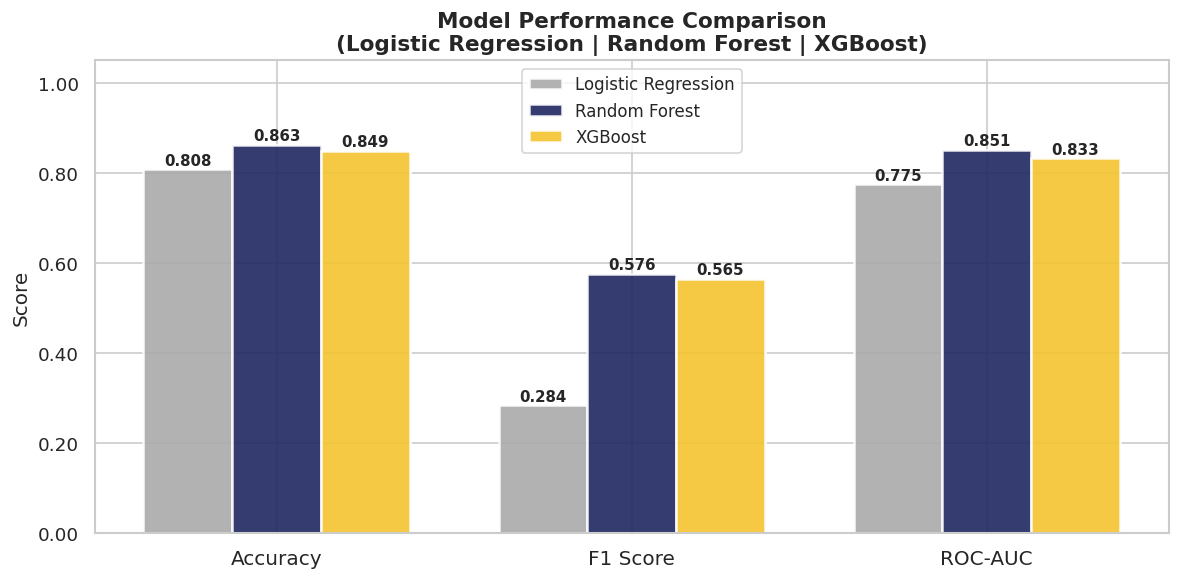

In [14]:
metrics   = ['Accuracy', 'F1 Score', 'ROC-AUC']
model_names = list(results_df.index)
x = np.arange(len(metrics))
width = 0.25
model_colors = [BRAND_GREY, BRAND_NAVY, BRAND_GOLD]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width - width, vals, width, label=name,
                  color=color, edgecolor='white', linewidth=1.5, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison\n(Logistic Regression | Random Forest | XGBoost)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart9_model_comparison.png', bbox_inches='tight')
plt.show()

### 2.4 ROC Curves

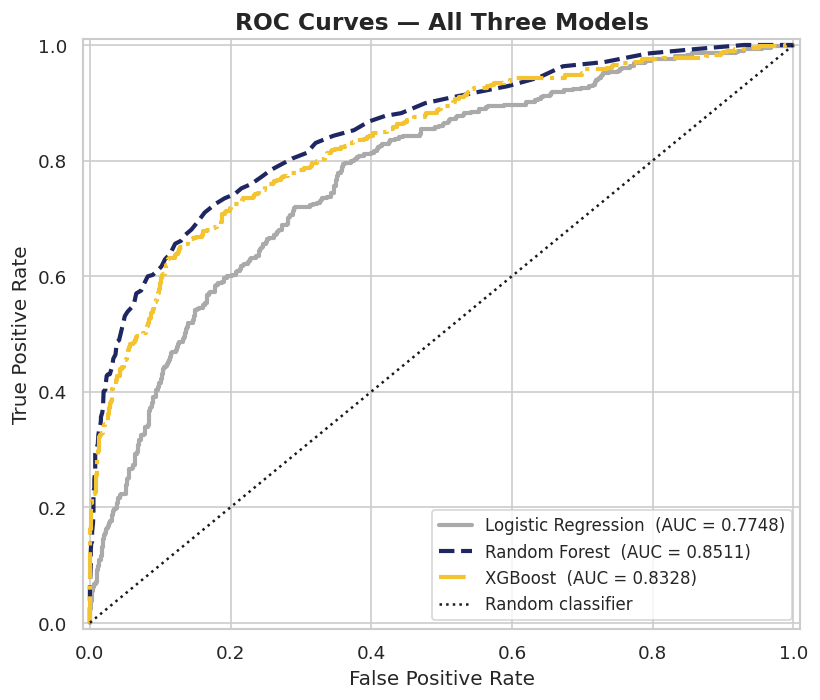

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
line_styles = ['-', '--', '-.']
colors = [BRAND_GREY, BRAND_NAVY, BRAND_GOLD]

for (name, y_prob), ls, color in zip(y_probs.items(), line_styles, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, ls=ls, color=color, lw=2.5, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], 'k:', lw=1.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Three Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart10_roc_curves.png', bbox_inches='tight')
plt.show()

### 2.5 Feature Importance — Random Forest

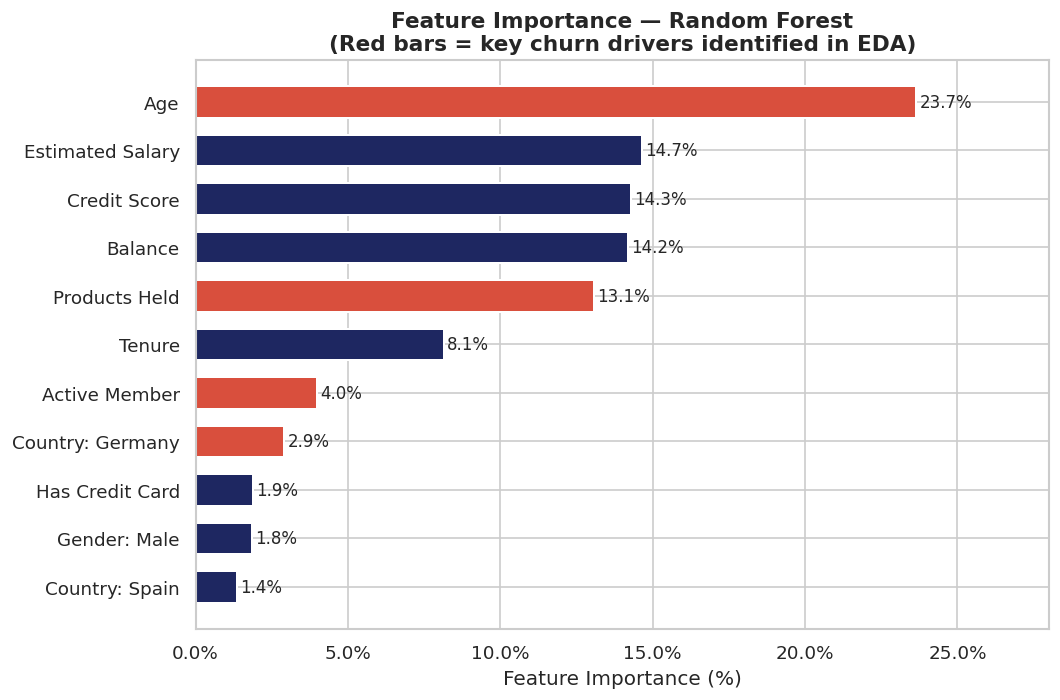


Top 5 features:
Age                23.6500
Estimated Salary   14.6600
Credit Score       14.2900
Balance            14.2000
Products Held      13.0600


In [16]:
rf = trained['Random Forest']
fi_rf = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
    .rename(FEATURE_LABELS)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [BRAND_RED if 'Age' in lbl or 'Product' in lbl or 'Active' in lbl or 'Germany' in lbl
              else BRAND_NAVY for lbl in fi_rf.index]

bars = ax.barh(fi_rf.index, fi_rf.values * 100,
               color=bar_colors, edgecolor='white', linewidth=1.2, height=0.65)
for bar, val in zip(bars, fi_rf.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Feature Importance (%)', fontsize=12)
ax.set_title('Feature Importance — Random Forest\n(Red bars = key churn drivers identified in EDA)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 28)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart11_feature_importance_rf.png', bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
print(fi_rf.sort_values(ascending=False).head(5).mul(100).round(2).to_string())

### 2.6 Feature Importance — XGBoost

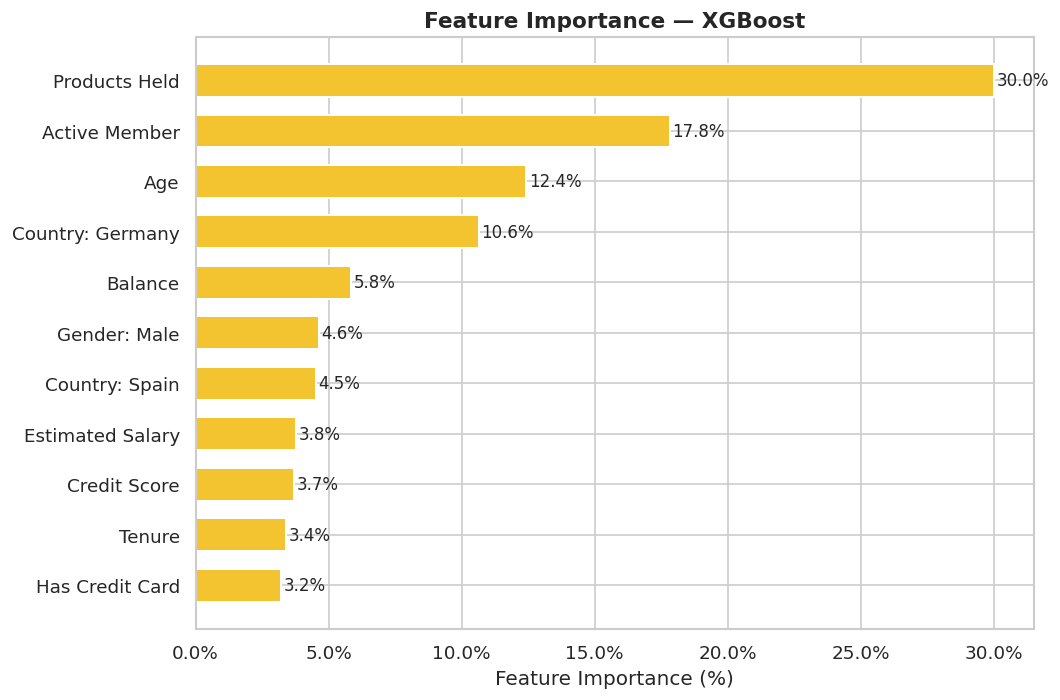

In [17]:
xgb = trained['XGBoost']
fi_xgb = (
    pd.Series(xgb.feature_importances_, index=X_train.columns)
    .rename(FEATURE_LABELS)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi_xgb.index, fi_xgb.values * 100,
               color=BRAND_GOLD, edgecolor='white', linewidth=1.2, height=0.65)
for bar, val in zip(bars, fi_xgb.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Feature Importance (%)', fontsize=12)
ax.set_title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart12_feature_importance_xgb.png', bbox_inches='tight')
plt.show()

### 2.7 Confusion Matrices

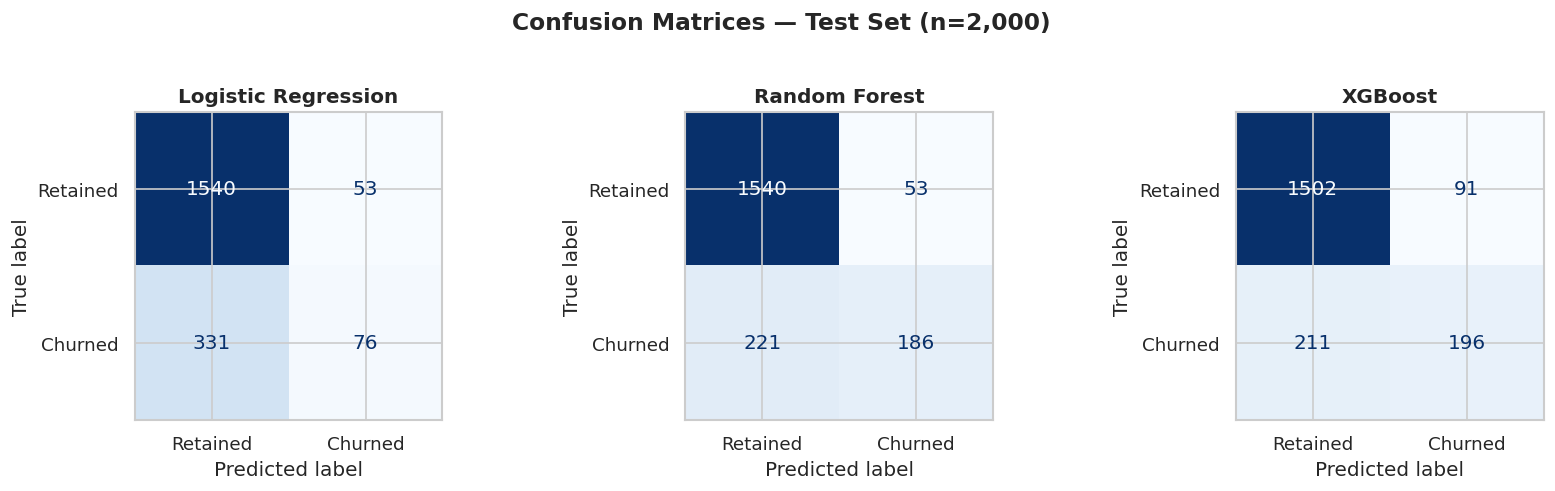

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Retained', 'Churned'],
        cmap='Blues',
        ax=ax,
        colorbar=False
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set (n=2,000)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart13_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 2.8 Classification Reports

In [19]:
for name, model in trained.items():
    y_pred = model.predict(X_test)
    print(f'── {name} ──')
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

── Logistic Regression ──
              precision    recall  f1-score   support

    Retained       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

── Random Forest ──
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

── XGBoost ──
              precision    recall  f1-score   support

    Retained       0.88      0.94      0.91      1593
     Churned       0.68      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg  

### 2.9 Cross-Validation (5-Fold ROC-AUC)

In [20]:
from sklearn.model_selection import cross_val_score

cv_results = {}
for name, model in trained.items():
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'CV AUC Mean': round(cv.mean(), 4), 'CV AUC Std': round(cv.std(), 4)}
    print(f'{name}: CV AUC = {cv.mean():.3f} +/- {cv.std():.3f}')

print()
cv_df = pd.DataFrame(cv_results).T
display(cv_df)

# Compare CV AUC vs test AUC to check for overfitting
print('\nTest AUC vs CV AUC (overfitting check):')
for name in trained:
    test_auc = results[name]['ROC-AUC']
    cv_auc   = cv_results[name]['CV AUC Mean']
    diff     = test_auc - cv_auc
    flag     = '  ⚠ possible overfit' if diff > 0.02 else '  ✓ stable'
    print(f'  {name:<25}  Test={test_auc:.3f}  CV={cv_auc:.3f}  Δ={diff:+.3f}{flag}')

Logistic Regression: CV AUC = 0.763 +/- 0.011


Random Forest: CV AUC = 0.858 +/- 0.008
XGBoost: CV AUC = 0.843 +/- 0.014



,CV AUC Mean,CV AUC Std
Logistic Regression,0.7633,0.0114
Random Forest,0.8575,0.0081
XGBoost,0.8431,0.0141



Test AUC vs CV AUC (overfitting check):
  Logistic Regression        Test=0.775  CV=0.763  Δ=+0.012  ✓ stable
  Random Forest              Test=0.851  CV=0.858  Δ=-0.006  ✓ stable
  XGBoost                    Test=0.833  CV=0.843  Δ=-0.010  ✓ stable


---
## 3. Final Model Comparison Table

In [21]:
print('=' * 62)
print('           FINAL MODEL COMPARISON SUMMARY')
print('=' * 62)
display(
    results_df.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#d4edda')  # green = best per metric
    .set_caption('All models evaluated on hold-out test set (n = 2,000)')
)

best = results_df['ROC-AUC'].idxmax()
print(f'\nBest model by AUC: {best} ({results_df.loc[best, "ROC-AUC"]:.4f})')
print(f'Best model by F1:  {results_df["F1 Score"].idxmax()} ({results_df["F1 Score"].max():.4f})')

           FINAL MODEL COMPARISON SUMMARY


,Accuracy,F1 Score,ROC-AUC
Logistic Regression,0.8080,0.2836,0.7748
Random Forest,0.8630,0.5759,0.8511
XGBoost,0.8490,0.5648,0.8328



Best model by AUC: Random Forest (0.8511)
Best model by F1:  Random Forest (0.5759)


---
## 4. The 3-Year Cost of Inaction

What happens financially if GlobalBank does nothing about churn?

In [22]:
import math

# ── Assumptions ────────────────────────────────────────────────────────────
customers        = 10_000
churn_rate       = 0.204          # observed annual churn rate
avg_balance      = 76_000         # mean balance across all customers (€)
revenue_pct      = 0.015          # bank earns ~1.5% of balance per year (NIM proxy)
acquisition_cost = 300            # cost to acquire one new customer (€)
years            = 3

# ── Year-by-year projection ────────────────────────────────────────────────
rows = []
current_customers = customers
cumulative_lost   = 0

for yr in range(1, years + 1):
    lost          = math.floor(current_customers * churn_rate)
    revenue_lost  = lost * avg_balance * revenue_pct
    replace_cost  = lost * acquisition_cost
    total_impact  = revenue_lost + replace_cost
    cumulative_lost += total_impact

    rows.append({
        'Year':                     yr,
        'Customers at Start':       current_customers,
        'Customers Lost (churn)':   lost,
        'Revenue Lost (€)':         revenue_lost,
        'Replacement Cost (€)':     replace_cost,
        'Total Annual Impact (€)':  total_impact,
        'Cumulative Impact (€)':    cumulative_lost,
    })
    current_customers -= lost

inaction_df = pd.DataFrame(rows)
display(
    inaction_df.style
    .format({
        'Customers at Start':      '{:,.0f}',
        'Customers Lost (churn)':  '{:,.0f}',
        'Revenue Lost (€)':        '€{:,.0f}',
        'Replacement Cost (€)':    '€{:,.0f}',
        'Total Annual Impact (€)': '€{:,.0f}',
        'Cumulative Impact (€)':   '€{:,.0f}',
    })
    .highlight_max(subset=['Total Annual Impact (€)'], color='#f8d7da')
    .set_caption('3-Year Cost of Inaction — GlobalBank Churn Model')
)

total_3yr = inaction_df['Total Annual Impact (€)'].sum()
total_lost = customers - inaction_df['Customers at Start'].iloc[-1] - math.floor(inaction_df['Customers at Start'].iloc[-1] * churn_rate)

print(f'\n{"="*55}')
print(f'  3-YEAR TOTAL COST OF INACTION: €{total_3yr:,.0f}')
print(f'  Customers lost over 3 years:   {customers - current_customers:,}')
print(f'  Customer base remaining:       {current_customers:,}')
print(f'{"="*55}')
print(f'\nAssumptions:')
print(f'  Annual churn rate    : {churn_rate*100:.1f}%')
print(f'  Avg customer balance : €{avg_balance:,}')
print(f'  Net interest margin  : {revenue_pct*100:.1f}% of balance/year')
print(f'  Acquisition cost     : €{acquisition_cost}/customer')

,Year,Customers at Start,Customers Lost (churn),Revenue Lost (€),Replacement Cost (€),Total Annual Impact (€),Cumulative Impact (€)
0,1,"10,000","2,039","€2,324,460","€611,700","€2,936,160","€2,936,160"
1,2,"7,961","1,624","€1,851,360","€487,200","€2,338,560","€5,274,720"
2,3,"6,337","1,292","€1,472,880","€387,600","€1,860,480","€7,135,200"



  3-YEAR TOTAL COST OF INACTION: €7,135,200
  Customers lost over 3 years:   4,955
  Customer base remaining:       5,045

Assumptions:
  Annual churn rate    : 20.4%
  Avg customer balance : €76,000
  Net interest margin  : 1.5% of balance/year
  Acquisition cost     : €300/customer


---
## 4. Key Conclusions

### Business Insights

1. **The Product Paradox is real.** Customers with 3+ products churn at 83–100%. The cross-selling programme is the single strongest predictor of departure. The bank should cap proactive product offers at 2 per customer.

2. **Germany is structurally broken.** At 32.4% churn (2× France/Spain), Germany needs a dedicated retention strategy — not just generic campaigns.

3. **Age is the #1 model feature.** Customers aged 40–60 are leaving at nearly double the rate of younger customers. The high-value segment (age 40–60, balance >€100k) alone represents 43.4% churn — these are the most expensive departures.

4. **Inactivity compounds risk.** Inactive + 3 products = 88.2% churn. A targeted win-back campaign for this 153-customer group could have immediate impact.

5. **Not all customers are worth retaining.** The low-value segment (balance <€10k, inactive, 1 product) churns at 47.1%. Retention spend here yields negative ROI.

### Model Recommendation

- **Random Forest** (AUC 0.851, F1 0.576) is the best overall model for this dataset.
- **XGBoost** is competitive (AUC 0.833) with further hyperparameter tuning potentially closing the gap.
- **Logistic Regression** serves as a useful interpretable baseline (AUC 0.775) but underperforms on recall for churned customers.

> *Generated for Analytics in Practise | Deadline 16 April*